In [1]:
# 필요한 라이브러리들 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# csv를 읽어와서 Pandas DataFrame으로 저장
data1 = pd.read_csv('data/2000_2001_hitter.csv')
data2 = pd.read_csv('data/2002_2013_hitter.csv')
data3 = pd.read_csv('data/2014_hitter.csv')

In [3]:
#파일을 합치기
df_combined = pd.concat([data1, data2, data3], ignore_index=True)
df_combined.sample(5)

,YrPlayer,Year,Rank,Player,Team,AVG,G,PA,AB,H,...,TA,RC,RC/27,wOBA,XR,R,SAC,MH,RISP,PH-BA
255,2005이숭용,2005,39,이숭용,현대,0.252,105,390,330,83,...,0.748062,50.441795,5.178435,0.341712,50.430,45.0,3.0,16.0,0.275,0.286
248,2005박종호,2005,32,박종호,삼성,0.268,119,484,392,105,...,0.699659,57.770702,4.859218,0.326288,57.226,63.0,25.0,30.0,0.263,0.000
100,2002송지만,2002,12,송지만,한화,0.291,131,557,488,142,...,0.964187,103.266356,7.638881,0.401599,97.992,84.0,0.0,37.0,0.295,0.000
345,2008조성환,2008,4,조성환,롯데,0.327,123,525,462,151,...,0.906250,90.620952,7.303778,0.366470,86.772,79.0,4.0,48.0,0.324,0.000
379,2008박진만,2008,38,박진만,삼성,0.244,104,391,332,81,...,0.613636,39.723529,3.885997,0.305359,40.210,28.0,9.0,20.0,0.247,0.000


In [4]:
df_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   YrPlayer  649 non-null    str    
 1   Year      649 non-null    int64  
 2   Rank      649 non-null    int64  
 3   Player    649 non-null    str    
 4   Team      649 non-null    str    
 5   AVG       649 non-null    float64
 6   G         649 non-null    int64  
 7   PA        649 non-null    int64  
 8   AB        649 non-null    int64  
 9   H         649 non-null    int64  
 10  1B        649 non-null    int64  
 11  2B        649 non-null    int64  
 12  3B        649 non-null    int64  
 13  HR        649 non-null    int64  
 14  RBI       649 non-null    int64  
 15  SB        648 non-null    float64
 16  CS        648 non-null    float64
 17  BB        649 non-null    int64  
 18  HBP       649 non-null    int64  
 19  SO        649 non-null    int64  
 20  GDP       649 non-null    int64  
 21  E   

In [6]:
df_combined['Player'].value_counts()

Player
박용택    12
박한이    12
홍성흔    11
정성훈    11
이진영    10
       ..
칸투      1
나바로     1
박민우     1
김성현     1
김재호     1
Name: count, Length: 224, dtype: int64

In [8]:
# 변수 선택
X = df_combined[['OPS','ISO','SECA','TA','RC','RC/27','wOBA','XR']] # 'HR'
y = df_combined['YrPlayer']

print(X.shape, y.shape)
display(X.head())
display(y.head())

(649, 8) (649,)


,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR
0,0.917819,0.149660,0.297052,0.976667,100.354529,8.286154,0.400138,92.804
1,1.017141,0.264392,0.379531,1.063830,115.473840,9.306847,0.431993,105.000
2,0.931997,0.195062,0.274074,0.931655,86.204956,8.224501,0.400969,77.820
3,1.031229,0.284188,0.423077,1.110092,119.916981,9.811389,0.436688,107.594
4,0.932665,0.231504,0.324582,0.923588,82.605677,7.125729,0.394586,80.284


0     2000박종호 
1     2000김동주 
2     2000브리또 
3     2000송지만 
4    2000데이비스 
Name: YrPlayer, dtype: str

In [11]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   OPS     649 non-null    float64
 1   ISO     649 non-null    float64
 2   SECA    649 non-null    float64
 3   TA      649 non-null    float64
 4   RC      649 non-null    float64
 5   RC/27   649 non-null    float64
 6   wOBA    649 non-null    float64
 7   XR      649 non-null    float64
dtypes: float64(8)
memory usage: 40.7 KB


In [9]:
X.describe()

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,0.812546,0.154515,0.288007,0.799547,72.640605,6.063903,0.354215,69.775458
std,0.107928,0.065458,0.086888,0.159885,22.210886,1.845858,0.041078,18.978558
min,0.573000,0.017208,0.099174,0.478571,29.373224,2.367394,0.258774,28.178000
25%,0.733000,0.103926,0.220994,0.680412,56.768750,4.796734,0.325362,56.322000
50%,0.805000,0.150358,0.276923,0.783394,68.763416,5.766099,0.352448,67.270000
75%,0.875000,0.195946,0.343750,0.889251,84.681818,6.988870,0.379460,81.298000
max,1.198000,0.398747,0.713896,1.531746,166.135175,14.726092,0.498024,144.746000


<Axes: >

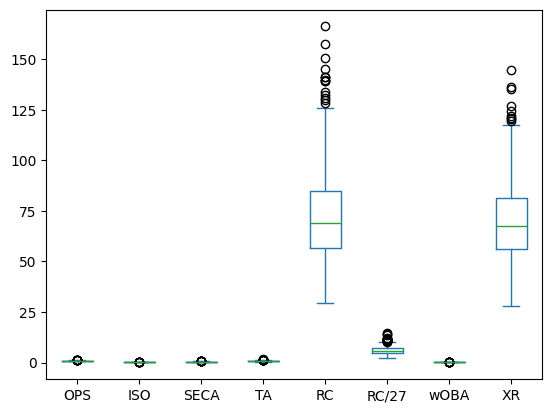

In [10]:
# 데이터 분포 확인(박스플롯)
X.plot(kind='box')

In [13]:
# 데이터 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.97614887, -0.07422939,  0.10417649, ...,  1.20484091,
         1.11880719,  1.21433377],
       [ 1.89711625,  1.67989079,  1.05416505, ...,  1.75823146,
         1.89486616,  1.85744936],
       [ 1.10761611,  0.61991005, -0.16048453, ...,  1.1714146 ,
         1.13904003,  0.42420225],
       ...,
       [-0.42233048, -0.05169927,  0.77350431, ..., -0.32541846,
        -0.43538549, -0.33597768],
       [-1.46085838, -1.39601302, -1.62726689, ..., -1.37885116,
        -1.47288829, -1.11957047],
       [-1.28467954, -1.24146838, -0.64887581, ..., -1.19083305,
        -1.21125882, -1.3345048 ]])

In [15]:
X.loc[:,:] = X_scaled
X.head()

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR
0,0.976149,-0.074229,0.104176,1.108646,1.248725,1.204841,1.118807,1.214334
1,1.897116,1.679891,1.054165,1.654227,1.929967,1.758231,1.894866,1.857449
2,1.107616,0.619910,-0.160485,0.826902,0.611178,1.171415,1.139040,0.424202
3,2.027750,1.982543,1.555727,1.943794,2.130165,2.031780,2.009248,1.994235
4,1.113814,1.177062,0.421269,0.776410,0.449003,0.575692,0.983538,0.554133


<Axes: >

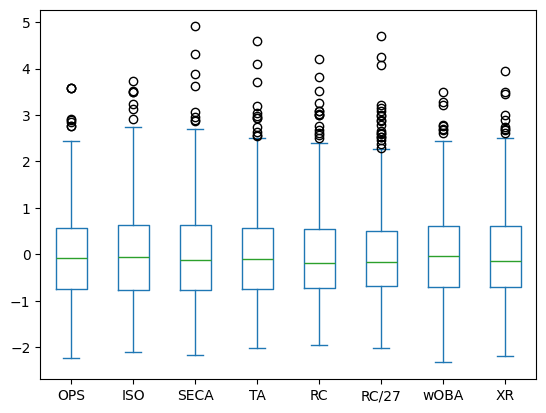

In [16]:
X.plot(kind='box')

In [ ]:
# 최적의 k 찾기

5192.000000000002
2225.9535725552355
1334.9614684794224
1022.9114281177136
867.7748463788823
733.3458299679609
675.7105078612263
611.8428717593748
559.424193246676


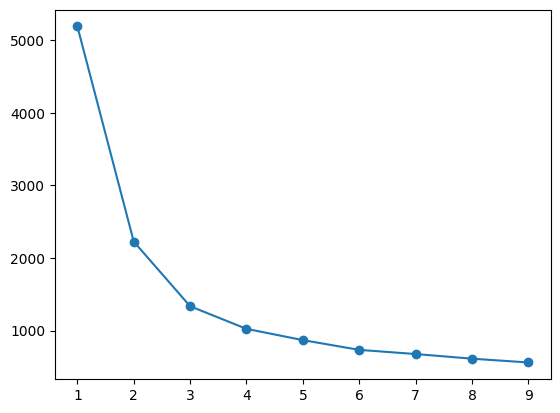

In [18]:
from sklearn.cluster import KMeans

# 엘보우 기법으로 최적의 k 찾기
inertia = []
for n in range(1, 10):
    km = KMeans(n_clusters=n, random_state=42) # random_state 고정
    km.fit(X)
    print(km.inertia_)
    inertia.append(km.inertia_)

# 그래프로 그리기 
plt.plot(range(1, 10), inertia, marker = 'o')
plt.show()

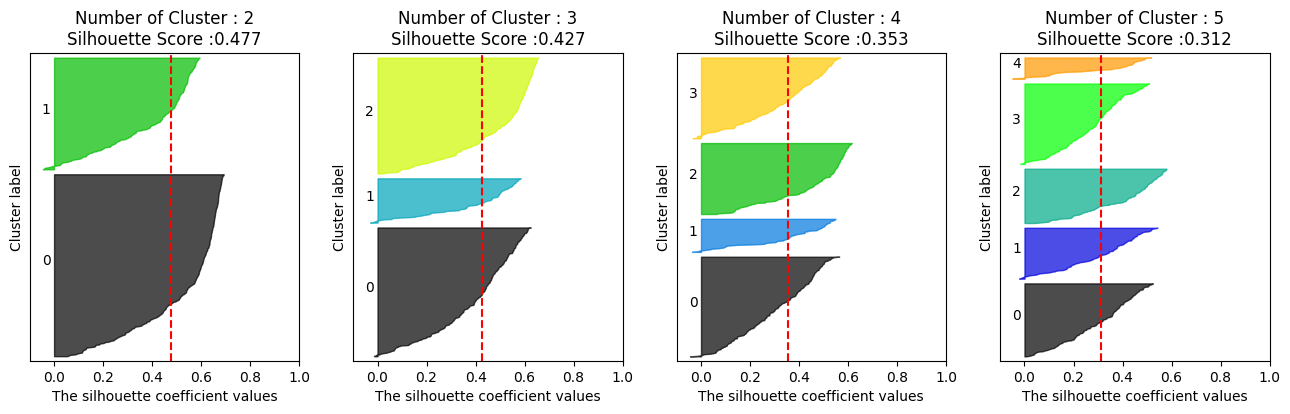

In [20]:
# 실루엣 점수 확인
visualize_silhouette([2, 3, 4, 5], X)

In [19]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

In [22]:
k = 3

km = KMeans(n_clusters = k, random_state = 42)
cluster = km.fit_predict(X)

In [25]:
from sklearn.metrics import silhouette_samples, silhouette_score

silhouette_score(X, cluster)

np.float64(0.4273993507604855)

In [26]:
# 군집화 결과 분석 

# 데이터프레임 생성
df = pd.DataFrame(X, columns=X.columns)
df['cluster'] = cluster
df.head()


,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster
0,0.976149,-0.074229,0.104176,1.108646,1.248725,1.204841,1.118807,1.214334,1
1,1.897116,1.679891,1.054165,1.654227,1.929967,1.758231,1.894866,1.857449,0
2,1.107616,0.619910,-0.160485,0.826902,0.611178,1.171415,1.139040,0.424202,1
3,2.027750,1.982543,1.555727,1.943794,2.130165,2.031780,2.009248,1.994235,0
4,1.113814,1.177062,0.421269,0.776410,0.449003,0.575692,0.983538,0.554133,1


In [27]:
df['cluster'].value_counts()

cluster
1    289
2    260
0    100
Name: count, dtype: int64

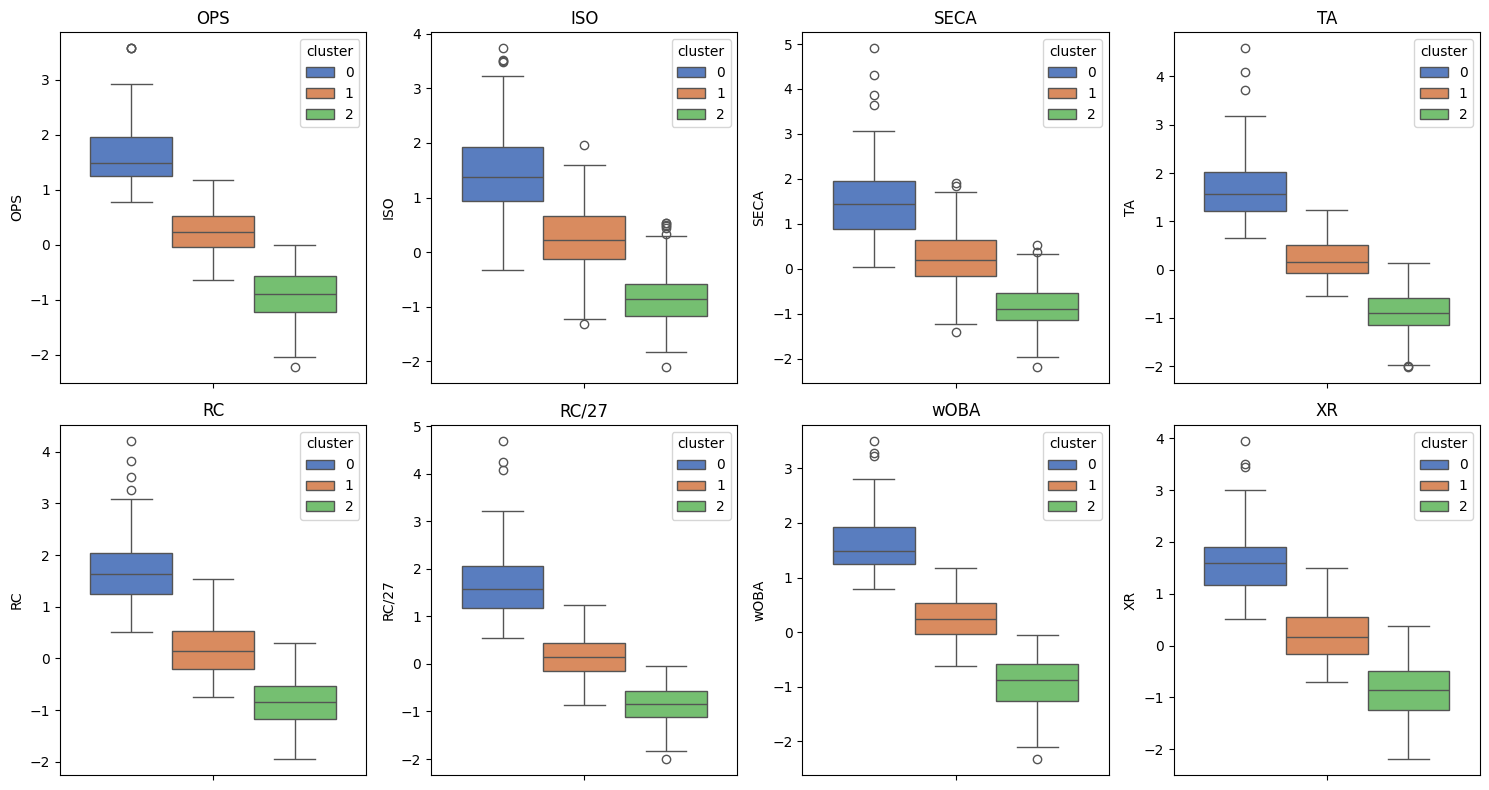

In [28]:
# 군집의 데이터 특징 분석
cols = df.columns[:-1]

plt.figure(figsize=(15,8))
for i, col in enumerate(cols):
    plt.subplot(2,4,i+1)
    sns.boxplot(data=df, y=col, hue='cluster', palette='muted')
    plt.title(col)
plt.tight_layout()

In [ ]:
# 각 군집별 한줄정리
0 번
1 번
2 번 

In [29]:
df

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster
0,0.976149,-0.074229,0.104176,1.108646,1.248725,1.204841,1.118807,1.214334,1
1,1.897116,1.679891,1.054165,1.654227,1.929967,1.758231,1.894866,1.857449,0
2,1.107616,0.619910,-0.160485,0.826902,0.611178,1.171415,1.139040,0.424202,1
3,2.027750,1.982543,1.555727,1.943794,2.130165,2.031780,2.009248,1.994235,0
4,1.113814,1.177062,0.421269,0.776410,0.449003,0.575692,0.983538,0.554133,1
...,...,...,...,...,...,...,...,...,...
644,0.412201,1.132233,1.026659,0.530672,-0.349031,0.204838,0.367294,-0.332603,1
645,-0.737598,-0.063556,-0.128516,-0.769272,-0.883686,-1.044144,-0.834318,-0.745176,2
646,-0.422330,-0.051699,0.773504,0.116640,-0.382668,-0.325418,-0.435385,-0.335978,1
647,-1.460858,-1.396013,-1.627267,-1.628601,-1.069759,-1.378851,-1.472888,-1.119570,2


In [30]:
#TODO:  데이터프레임에 개별 데이터 실루엣 계수 컬럼 추가
df['silhouette'] = silhouette_samples(X, cluster)
df

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette
0,0.976149,-0.074229,0.104176,1.108646,1.248725,1.204841,1.118807,1.214334,1,0.081953
1,1.897116,1.679891,1.054165,1.654227,1.929967,1.758231,1.894866,1.857449,0,0.563333
2,1.107616,0.619910,-0.160485,0.826902,0.611178,1.171415,1.139040,0.424202,1,0.292713
3,2.027750,1.982543,1.555727,1.943794,2.130165,2.031780,2.009248,1.994235,0,0.584445
4,1.113814,1.177062,0.421269,0.776410,0.449003,0.575692,0.983538,0.554133,1,0.306740
...,...,...,...,...,...,...,...,...,...,...
644,0.412201,1.132233,1.026659,0.530672,-0.349031,0.204838,0.367294,-0.332603,1,0.521233
645,-0.737598,-0.063556,-0.128516,-0.769272,-0.883686,-1.044144,-0.834318,-0.745176,2,0.436265
646,-0.422330,-0.051699,0.773504,0.116640,-0.382668,-0.325418,-0.435385,-0.335978,1,0.258634
647,-1.460858,-1.396013,-1.627267,-1.628601,-1.069759,-1.378851,-1.472888,-1.119570,2,0.601221


In [34]:
# 잘못 군집화 된 클러스터
df.loc[df['silhouette']<0]

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette,player
73,-0.216228,-0.031499,-0.430329,-0.320923,-0.535748,-0.273093,-0.277078,-0.538362,1,-0.013725,2001신동주
117,-0.292514,0.079612,-0.277797,-0.490323,-0.401925,-0.494923,-0.365701,-0.354750,1,-0.014669,2002박재홍
170,1.209642,0.135326,0.503056,1.165596,0.875338,1.375800,1.325860,0.763689,0,-0.030222,2004이진영
252,-0.385240,-0.189322,0.336917,-0.300036,-0.607962,-0.512545,-0.351908,-0.567786,1,-0.005997,2005양준혁
390,0.912920,0.634119,1.146273,1.044780,1.014958,0.870847,0.999051,0.993283,0,-0.004194,2009강봉규
475,1.070553,0.938210,0.769761,1.190167,0.779519,0.959467,1.112819,0.801445,0,-0.008561,2011최정
546,0.245295,-0.727183,-1.407866,-0.261230,-0.427817,0.281310,0.240336,-0.603538,1,-0.007312,2013이병규
552,1.181824,0.649081,0.580234,1.166846,0.737684,1.252473,1.345286,0.630700,0,-0.014241,2013박석민
623,0.950010,1.444742,0.552413,0.647838,1.218206,0.731987,0.857464,1.251773,0,-0.018446,2014이승엽


In [33]:
df['player'] = y

In [37]:
#TODO: 클러스터 별 중심 player
max_idx = df.groupby('cluster')['silhouette'].idxmax()
df.loc[max_idx]

,OPS,ISO,SECA,TA,RC,RC/27,wOBA,XR,cluster,silhouette,player
3,2.027750,1.982543,1.555727,1.943794,2.130165,2.031780,2.009248,1.994235,0,0.584445,2000송지만
224,0.477109,0.528070,0.292849,0.506997,0.144334,0.438000,0.405998,0.144724,1,0.624981,2005클리어
84,-1.075863,-0.856633,-0.932228,-1.192854,-1.099995,-1.095172,-1.014036,-1.155744,2,0.655743,2001채종범


In [ ]:
# 전체 주성분 계산

from sklearn.decomposition import PCA



(649, 8)

In [ ]:
# 컬럼별 설명된 분산 비율 확인
explained_variance = pca.explained_variance_ratio_
explained_variance

array([9.05145728e-01, 5.06261666e-02, 2.18885403e-02, 1.84561022e-02,
       2.99299164e-03, 5.56239341e-04, 1.83919162e-04, 1.50312428e-04])

In [ ]:
# 누적분산 확인
cumulative_variance = explained_variance.cumsum()
cumulative_variance

array([0.90514573, 0.95577189, 0.97766044, 0.99611654, 0.99910953,
       0.99966577, 0.99984969, 1.        ])

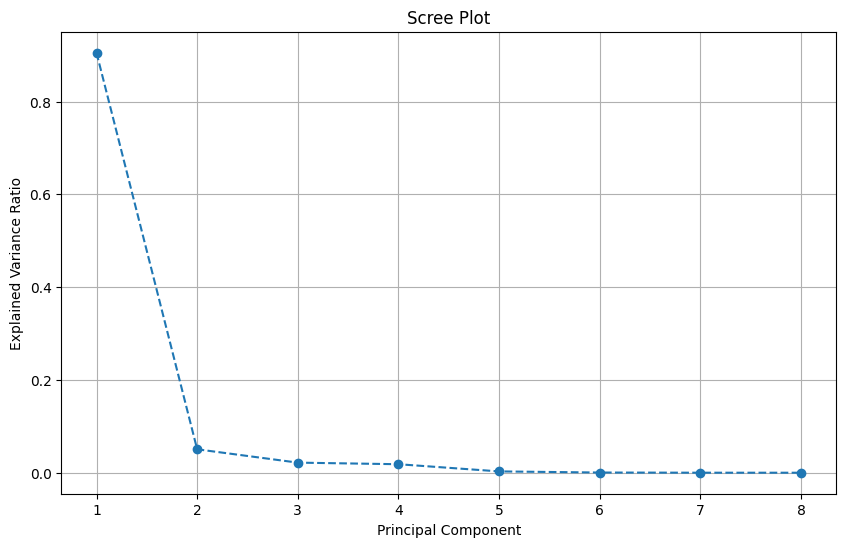

In [14]:
# Plot Scree Chart
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, len(explained_variance) + 1, 1))
plt.grid()
plt.show()

In [ ]:
# 최적의 주성분 개수 선택 (예: 95% 이상의 분산을 설명하는 최소 주성분 개수)


1

In [ ]:
# 2개의 주성분으로 변환하기 
from sklearn.decomposition import PCA

# PCA 수행



array([[ 2.48864775, -1.29871071],
       [ 4.8638416 , -0.32843484],
       [ 2.05850718, -0.4397998 ],
       ...,
       [-0.3971905 ,  0.69084294],
       [-3.94087277, -0.42488303],
       [-3.33227219,  0.22550401]])

In [21]:
# PCA 설명된 분산 비율 출력


array([0.90514573, 0.05062617])

In [18]:
# pc1, pc2로 결과 데이터프레임 생성 


,principal component 1,principal component 2
0,2.488648,-1.298711
1,4.863842,-0.328435
2,2.058507,-0.439800
3,5.544865,-0.087107
4,2.134990,0.387255
...,...,...
644,1.024438,1.383975
645,-1.873179,0.821719
646,-0.397191,0.690843
647,-3.940873,-0.424883


In [ ]:
# 주성분으로 군집화
k = 4



In [ ]:
# 군집 결과 시각화

In [ ]:
# PCA를 전후 군집 결과 비교